In [ ]:
# Group member: Xingjian (James) Tian, Baiche (Linda) Xu, Taiyaxin (Tanya) Liu

In [10]:
from google.colab import files

uploaded = files.upload()

Saving Carseat_sales.csv to Carseat_sales (2).csv
Saving diabetes_dataset.csv to diabetes_dataset.csv


In [11]:
import os
print(os.listdir())

['.config', 'diabetes_dataset (1) (1).csv', 'diabetes_dataset (1).csv', 'diabetes_dataset.csv', 'Carseat_sales (1).csv', 'Carseat_sales (2).csv', 'Carseat_sales.csv', 'sample_data']


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

class ISTA_LASSO:
    def __init__(self, alpha=1.0, max_iter=1000, tol=1e-4, learning_rate=None):
        self.alpha = alpha
        self.max_iter = max_iter
        self.tol = tol
        self.learning_rate = learning_rate
        self.coef_ = None
        self.history = {'loss': [], 'coef': []}

    def soft_threshold(self, x, threshold):
        return np.sign(x) * np.maximum(np.abs(x) - threshold, 0)

    def compute_lipschitz(self, X):
        if len(X) == 0:
            return 1.0
        L = np.linalg.norm(X.T @ X, 2)
        return L

    def fit(self, X, y):
        n_samples, n_features = X.shape
        w = np.zeros(n_features)
        L = self.compute_lipschitz(X)
        eta = 1.0 / L if self.learning_rate is None else self.learning_rate

        for i in range(self.max_iter):
            residual = X @ w - y
            gradient = X.T @ residual
            w_step = w - eta * gradient
            w_new = self.soft_threshold(w_step, eta * self.alpha)

            if np.linalg.norm(w_new - w) < self.tol:
                break
            w = w_new
            self.history['loss'].append(0.5 * np.sum(residual ** 2) + self.alpha * np.sum(np.abs(w)))
            self.history['coef'].append(w.copy())

        self.coef_ = w
        return self

    def predict(self, X):
        return X @ self.coef_

    def get_sparsity(self):
        return np.mean(self.coef_ == 0)

def preprocess_data(X, y, test_size=0.2, random_state=42):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    X_scaled = np.hstack([np.ones((X_scaled.shape[0], 1)), X_scaled])
    return train_test_split(X_scaled, y, test_size=test_size, random_state=random_state), scaler

def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    mse = np.mean((y_test - y_pred) ** 2)
    r2 = 1 - np.sum((y_test - y_pred)**2) / np.sum((y_test - np.mean(y_test))**2)
    return {'mse': mse, 'r2': r2, 'sparsity': model.get_sparsity()}


In [13]:
# Load diabetes dataset
df_dia = pd.read_csv("diabetes_dataset.csv")
X_dia = df_dia.drop("target", axis=1).values
y_dia = df_dia["target"].values
(X_train_dia, X_test_dia, y_train_dia, y_test_dia), _ = preprocess_data(X_dia, y_dia)

# Load carseat sales dataset
df_car = pd.read_csv("Carseat_sales.csv")
df_car = pd.get_dummies(df_car, columns=["ShelveLoc", "Urban", "US"], drop_first=True)
X_car = df_car.drop("Sales", axis=1).values
y_car = df_car["Sales"].values
(X_train_car, X_test_car, y_train_car, y_test_car), _ = preprocess_data(X_car, y_car)


In [14]:
# Diabetes model
ista_dia = ISTA_LASSO(alpha=0.1)
ista_dia.fit(X_train_dia, y_train_dia)
results_dia = evaluate_model(ista_dia, X_test_dia, y_test_dia)

# Carseat model
ista_car = ISTA_LASSO(alpha=0.5)
ista_car.fit(X_train_car, y_train_car)
results_car = evaluate_model(ista_car, X_test_car, y_test_car)

print("Diabetes Dataset:", results_dia)
print("Car Seat Dataset:", results_car)

Diabetes Dataset: {'mse': np.float64(2896.9857572852516), 'r2': np.float64(0.4532082328339573), 'sparsity': np.float64(0.0)}
Car Seat Dataset: {'mse': np.float64(1.0940849291276127), 'r2': np.float64(0.8894439628882845), 'sparsity': np.float64(0.0)}


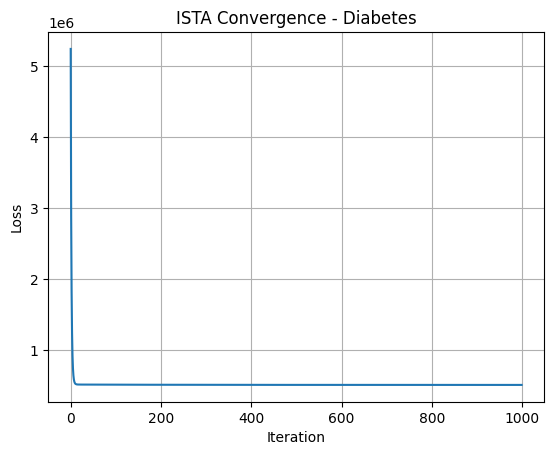

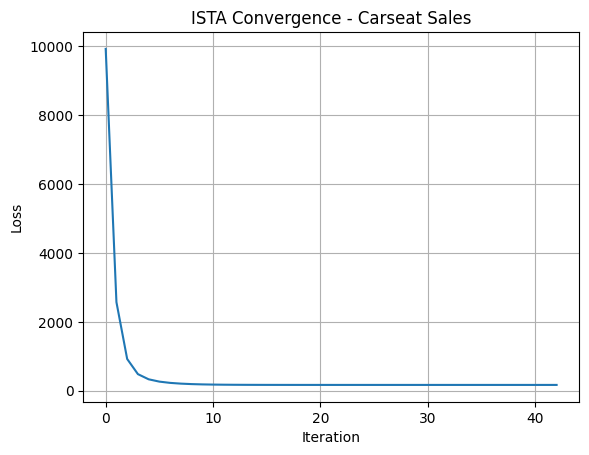

In [15]:
plt.plot(ista_dia.history['loss'])
plt.title("ISTA Convergence - Diabetes")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

plt.plot(ista_car.history['loss'])
plt.title("ISTA Convergence - Carseat Sales")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.grid(True)
plt.show()